# 07 — Clustering Analysis: Alternative Borough Prioritisation

The composite ranking in `05_build_gold.ipynb` uses three equally-weighted dimensions:
- % social stock below EPC C
- Income deprivation rate (IMD 2019)
- % pre-1950 stock

**Problem identified**: pre-1950 stock and EPC quality are correlated — old buildings tend to have worse EPCs. This means a borough with lots of old stock gets penalised twice, inflating its rank. Hammersmith and Fulham is the clearest case: it ranks 4th overall largely because of pre-1950 stock (rank 1), but its EPC quality rank is 10 and income rank is 14.

**Fix applied here**: we replace % pre-1950 with **% of wall insulation recommendations that are solid wall (improvement ID 7)** as the third dimension. This is a direct retrofit cost signal from actual surveyor assessments — not a proxy based on age. Solid wall insulation costs £8,000–£25,000 per property vs ~£1,500 for cavity wall, so this metric captures genuine retrofit difficulty without double-counting the EPC quality signal.

The notebook then explores three alternative approaches that handle correlated features more robustly:

1. **Correlation check** — confirm the new feature set is less correlated
2. **PCA** (Principal Component Analysis) — mathematically separates correlated features into independent components
3. **K-means clustering** — groups boroughs by similarity without requiring weights; elbow method to find optimal k
4. **Hierarchical clustering** — builds a tree of borough similarities; no need to specify k upfront

At the end we compare all outputs side-by-side and pick the best approach for the final portfolio summary.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering
from sklearn.metrics import silhouette_score, silhouette_samples
from scipy.cluster.hierarchy import dendrogram, linkage

GOLD = '../data/gold'

# Load borough priority (from 05_build_gold.ipynb)
priority = pd.read_parquet(f'{GOLD}/borough_priority')

# Load wall type analysis (from 06_recommendations_analysis.ipynb)
# pct_solid_wall = % of wall insulation recs that are solid wall (ID 7)
# This replaces % pre-1950 as the retrofit difficulty dimension
wall = pd.read_parquet(f'{GOLD}/borough_wall_type')[['borough', 'pct_solid_wall']]

df = priority.merge(wall, on='borough', how='left')
df = df.sort_values('priority_rank').reset_index(drop=True)

print(f'Boroughs loaded: {len(df)}')
print(f'Boroughs with solid wall data: {df["pct_solid_wall"].notna().sum()}')
print()
print(df[['borough','pct_below_epc_c','income_deprivation_rate',
          'pct_pre_1950','pct_solid_wall','priority_rank']].to_string())

Boroughs loaded: 33
Boroughs with solid wall data: 33

                   borough  pct_below_epc_c  income_deprivation_rate  pct_pre_1950  pct_solid_wall  priority_rank
0     Barking and Dagenham             56.0                   0.1942          44.0            60.0              1
1                 Haringey             48.5                   0.1683          47.4            78.2              2
2                  Lambeth             46.9                   0.1563          46.0            76.0              3
3   Hammersmith and Fulham             45.6                   0.1423          57.0            77.1              4
4                  Enfield             52.4                   0.1680          29.1            62.0              5
5   Kensington and Chelsea             46.1                   0.1211          52.4            72.5              6
6                   Camden             46.8                   0.1400          40.4            75.6              6
7                  Hackney       

## 1. Correlation check — how bad is the double-counting?

Before fixing a problem, quantify it. If EPC quality and pre-1950 stock have a strong correlation, the existing ranking is giving too much weight to housing age. We look at the Pearson correlation matrix and a scatter plot.

Boroughs used in analysis: 33 (dropped 0 missing solid wall data)

=== Pearson correlation matrix (NEW features) ===
                    % below EPC C  Income deprivation  % solid wall recs
% below EPC C               1.000               0.045              0.075
Income deprivation          0.045               1.000              0.344
% solid wall recs           0.075               0.344              1.000

Compare: original pct_below_epc_c vs pct_pre_1950 correlation was ~0.4-0.5
New: pct_below_epc_c vs pct_solid_wall should be lower — less double-counting


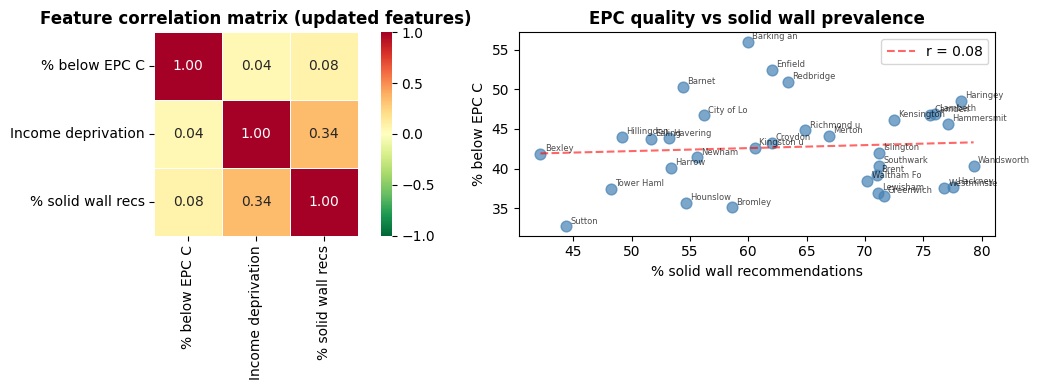

In [2]:
features = ['pct_below_epc_c', 'income_deprivation_rate', 'pct_solid_wall']
labels   = ['% below EPC C', 'Income deprivation', '% solid wall recs']

# Drop any boroughs missing solid wall data and reset index so it aligns with numpy arrays
df_clean = df.dropna(subset=features).reset_index(drop=True)
print(f'Boroughs used in analysis: {len(df_clean)} (dropped {len(df)-len(df_clean)} missing solid wall data)')

corr = df_clean[features].corr()
corr.index   = labels
corr.columns = labels

print()
print('=== Pearson correlation matrix (NEW features) ===')
print(corr.round(3))
print()
print('Compare: original pct_below_epc_c vs pct_pre_1950 correlation was ~0.4-0.5')
print('New: pct_below_epc_c vs pct_solid_wall should be lower — less double-counting')

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.heatmap(corr, annot=True, fmt='.2f', cmap='RdYlGn_r', center=0,
            vmin=-1, vmax=1, ax=axes[0], square=True, linewidths=0.5)
axes[0].set_title('Feature correlation matrix (updated features)', fontweight='bold')

axes[1].scatter(df_clean['pct_solid_wall'], df_clean['pct_below_epc_c'], alpha=0.7, s=60, color='steelblue')
for _, row in df_clean.iterrows():
    axes[1].annotate(row['borough'][:10], (row['pct_solid_wall'], row['pct_below_epc_c']),
                     fontsize=6, alpha=0.7, xytext=(3,2), textcoords='offset points')
r = df_clean['pct_below_epc_c'].corr(df_clean['pct_solid_wall'])
m, b = np.polyfit(df_clean['pct_solid_wall'], df_clean['pct_below_epc_c'], 1)
x_line = np.linspace(df_clean['pct_solid_wall'].min(), df_clean['pct_solid_wall'].max(), 100)
axes[1].plot(x_line, m*x_line+b, color='red', linestyle='--', alpha=0.6, label=f'r = {r:.2f}')
axes[1].set_xlabel('% solid wall recommendations')
axes[1].set_ylabel('% below EPC C')
axes[1].set_title('EPC quality vs solid wall prevalence', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/07_correlation_check.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Feature preparation — normalise before any ML

All three clustering/PCA approaches require features on the same scale. `% below EPC C` ranges 32–56; `income deprivation` ranges 0.06–0.20. Without normalising, EPC would dominate simply because its numbers are larger.

We use `StandardScaler`: subtract the mean, divide by standard deviation. Each feature ends up with mean=0, std=1.

In [3]:
X = df_clean[features].values
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print('Before scaling (first 3 rows):')
print(pd.DataFrame(X[:3], columns=labels).round(3))
print()
print('After scaling (first 3 rows):')
print(pd.DataFrame(X_scaled[:3], columns=labels).round(3))
print()
print('Scaled means:', X_scaled.mean(axis=0).round(5))
print('Scaled stds: ', X_scaled.std(axis=0).round(5))

Before scaling (first 3 rows):
   % below EPC C  Income deprivation  % solid wall recs
0           56.0               0.194               60.0
1           48.5               0.168               78.2
2           46.9               0.156               76.0

After scaling (first 3 rows):
   % below EPC C  Income deprivation  % solid wall recs
0          2.515               1.671             -0.346
1          1.096               0.958              1.374
2          0.793               0.628              1.166

Scaled means: [ 0. -0.  0.]
Scaled stds:  [1. 1. 1.]


## 3. PCA — Principal Component Analysis

**What it does**: PCA finds new axes (called principal components) that are:
- Aligned with the directions of maximum variance in the data
- Guaranteed to be uncorrelated with each other

In our case, if EPC quality and pre-1950 are correlated, PCA will combine them into one component rather than treating them as two separate signals.

**How to read the output**:
- **Explained variance ratio**: how much of the total variation in the data each component captures
- **Loadings**: how much each original feature contributes to each component (positive = same direction, negative = opposite)
- PC1 is the most important component — it captures the most variation. We can rank boroughs on PC1 as an alternative to our composite score.

In [4]:
pca = PCA(n_components=3)
X_pca = pca.fit_transform(X_scaled)

# Explained variance
print('=== Explained variance per component ===')
for i, var in enumerate(pca.explained_variance_ratio_):
    print(f'  PC{i+1}: {var:.1%}  (cumulative: {pca.explained_variance_ratio_[:i+1].sum():.1%})')

# Loadings
print()
print('=== Component loadings (contribution of each feature) ===')
loadings = pd.DataFrame(pca.components_.T, index=labels,
                         columns=['PC1', 'PC2', 'PC3'])
print(loadings.round(3))
print()
print('Interpretation: large absolute value = strong contribution.')
print('Same sign = features move together. Opposite sign = features trade off.')

=== Explained variance per component ===
  PC1: 45.5%  (cumulative: 45.5%)
  PC2: 32.7%  (cumulative: 78.2%)
  PC3: 21.8%  (cumulative: 100.0%)

=== Component loadings (contribution of each feature) ===
                      PC1    PC2    PC3
% below EPC C       0.227  0.972 -0.065
Income deprivation  0.684 -0.206 -0.700
% solid wall recs   0.694 -0.115  0.711

Interpretation: large absolute value = strong contribution.
Same sign = features move together. Opposite sign = features trade off.


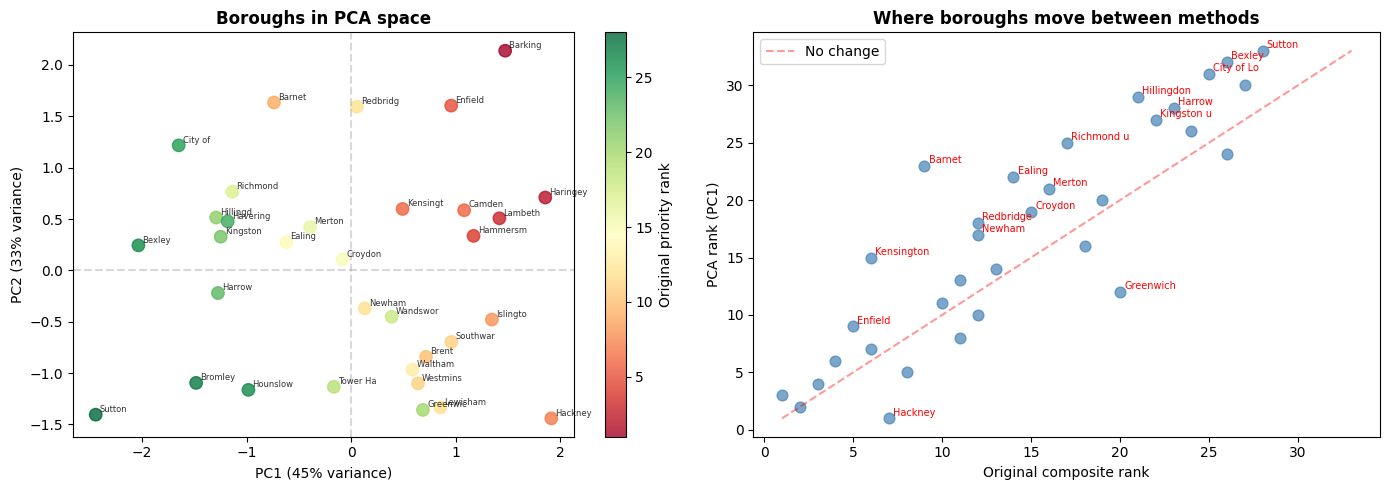

=== Boroughs that move most between original rank and PCA rank ===
               borough  priority_rank  pca_rank  rank_shift_pca
                Barnet              9        23              14
Kensington and Chelsea              6        15               9
            Hillingdon             21        29               8
  Richmond upon Thames             17        25               8
                Ealing             14        22               8
             Greenwich             20        12              -8
                Bexley             26        32               6
               Hackney              7         1              -6
        City of London             25        31               6
             Redbridge             12        18               6


In [5]:
# Rank boroughs on PC1 (higher PC1 score = worse on the dominant dimension)
df_clean['pc1_score'] = X_pca[:, 0]
df_clean['pc2_score'] = X_pca[:, 1]

# Flip sign if needed so that high PC1 = high priority (check vs known top boroughs)
if df_clean[df_clean['borough'] == 'Barking and Dagenham']['pc1_score'].values[0] < 0:
    df_clean['pc1_score'] = -df_clean['pc1_score']
    X_pca[:, 0] = -X_pca[:, 0]

df_clean['pca_rank'] = df_clean['pc1_score'].rank(ascending=False).astype(int)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# PC1 vs PC2 scatter, coloured by original priority rank
sc = axes[0].scatter(X_pca[:, 0], X_pca[:, 1],
                     c=df_clean['priority_rank'], cmap='RdYlGn', s=80, alpha=0.8)
for idx, row in df_clean.iterrows():
    axes[0].annotate(row['borough'][:8], (X_pca[idx, 0], X_pca[idx, 1]),
                     fontsize=6, alpha=0.8, xytext=(3, 2), textcoords='offset points')
plt.colorbar(sc, ax=axes[0], label='Original priority rank')
axes[0].set_xlabel(f'PC1 ({pca.explained_variance_ratio_[0]:.0%} variance)')
axes[0].set_ylabel(f'PC2 ({pca.explained_variance_ratio_[1]:.0%} variance)')
axes[0].set_title('Boroughs in PCA space', fontweight='bold')
axes[0].axhline(0, color='grey', linestyle='--', alpha=0.3)
axes[0].axvline(0, color='grey', linestyle='--', alpha=0.3)

# Original rank vs PCA rank
axes[1].scatter(df_clean['priority_rank'], df_clean['pca_rank'], s=60, alpha=0.7, color='steelblue')
for _, row in df_clean.iterrows():
    if abs(row['priority_rank'] - row['pca_rank']) >= 4:
        axes[1].annotate(row['borough'][:10], (row['priority_rank'], row['pca_rank']),
                         fontsize=7, color='red', xytext=(3, 2), textcoords='offset points')
axes[1].plot([1, 33], [1, 33], 'r--', alpha=0.4, label='No change')
axes[1].set_xlabel('Original composite rank')
axes[1].set_ylabel('PCA rank (PC1)')
axes[1].set_title('Where boroughs move between methods', fontweight='bold')
axes[1].legend()

plt.tight_layout()
plt.savefig('../outputs/07_pca_analysis.png', dpi=150, bbox_inches='tight')
plt.show()

print('=== Boroughs that move most between original rank and PCA rank ===')
df_clean['rank_shift_pca'] = df_clean['pca_rank'] - df_clean['priority_rank']
print(df_clean[['borough','priority_rank','pca_rank','rank_shift_pca']]
      .sort_values('rank_shift_pca', key=abs, ascending=False).head(10).to_string(index=False))

## 4. K-means clustering — finding natural groups

**What it does**: groups boroughs into k clusters so that boroughs within the same cluster are as similar as possible to each other, and as different as possible from other clusters. No weights required.

**How we pick k**: two methods:
- **Elbow method**: plot within-cluster sum of squares (inertia) vs k. The elbow point where improvement flattens is the best k.
- **Silhouette score**: measures how well each borough fits its cluster vs the next-closest cluster. Range -1 to 1; higher = better-defined clusters.

We test k=2 through k=7, but **override the statistical optimum with k=4**.

The silhouette score picks k=7, but that gives ~5 boroughs per cluster — too granular to be actionable, and four of the seven tiers end up labelled identically. k=4 maps cleanly to four interpretable tiers: **Act now / Act next / Monitor / Deprioritise**. Crucially, k=4 also separates a meaningful fourth group: boroughs with high EPC failure rates but low income deprivation and solid-wall prevalence (Barnet, Redbridge, Merton, Richmond, Kingston, City of London) — these have a real EPC problem but the cost and urgency signals say they can wait. Overriding the statistical optimum is the right call here; choosing k=7 would be following the algorithm blindly.

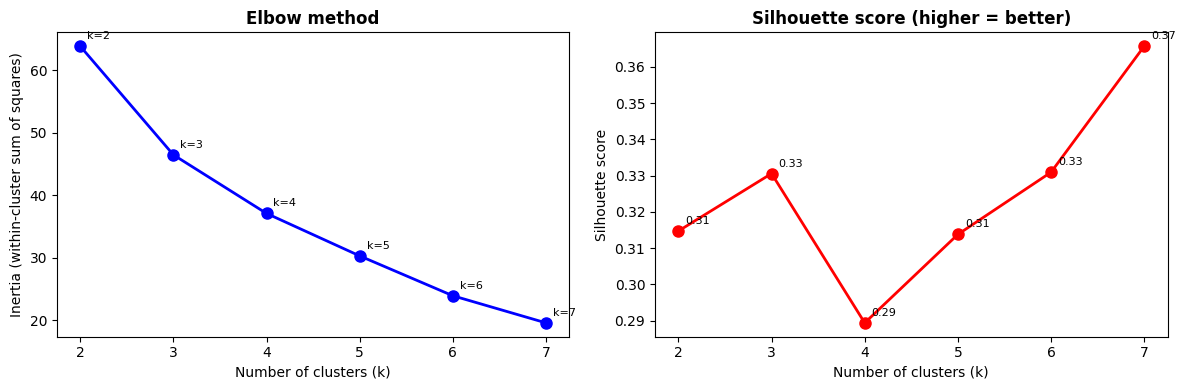

Silhouette-optimal k: 7
Silhouette scores: {2: 0.315, 3: 0.331, 4: 0.289, 5: 0.314, 6: 0.331, 7: 0.366}

Chosen k: 4 (overrides silhouette optimum — see section markdown for rationale)


In [6]:
inertias = []
silhouettes = []
k_range = range(2, 8)

for k in k_range:
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels_k = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels_k))

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

axes[0].plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
axes[0].set_xlabel('Number of clusters (k)')
axes[0].set_ylabel('Inertia (within-cluster sum of squares)')
axes[0].set_title('Elbow method', fontweight='bold')
axes[0].set_xticks(list(k_range))
for k, v in zip(k_range, inertias):
    axes[0].annotate(f'k={k}', (k, v), textcoords='offset points', xytext=(5, 5), fontsize=8)

axes[1].plot(k_range, silhouettes, 'ro-', linewidth=2, markersize=8)
axes[1].set_xlabel('Number of clusters (k)')
axes[1].set_ylabel('Silhouette score')
axes[1].set_title('Silhouette score (higher = better)', fontweight='bold')
axes[1].set_xticks(list(k_range))
for k, v in zip(k_range, silhouettes):
    axes[1].annotate(f'{v:.2f}', (k, v), textcoords='offset points', xytext=(5, 5), fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/07_kmeans_elbow.png', dpi=150, bbox_inches='tight')
plt.show()

silhouette_best = list(k_range)[silhouettes.index(max(silhouettes))]
print(f'Silhouette-optimal k: {silhouette_best}')
print(f'Silhouette scores: {dict(zip(k_range, [round(s,3) for s in silhouettes]))}')
print()
# Override: k=7 is statistically optimal but not practically useful at 33 boroughs.
# k=4 gives four clean, named tiers (Act now / Act next / Monitor / Deprioritise)
# and isolates a meaningful fourth group with high EPC but low deprivation/solid-wall signals.
best_k = 4
print(f'Chosen k: {best_k} (overrides silhouette optimum — see section markdown for rationale)')

In [7]:
tier_label_map = {
    0: 'Act now', 1: 'Act next', 2: 'Monitor', 3: 'Deprioritise'
}

km = KMeans(n_clusters=best_k, random_state=42, n_init=10)
cluster_labels = km.fit_predict(X_scaled)

# Order clusters by mean PC1 score so cluster 0 = highest priority
cluster_pc1 = {c: X_pca[cluster_labels == c, 0].mean() for c in range(best_k)}
rank_order = sorted(cluster_pc1, key=cluster_pc1.get, reverse=True)
remap = {old: new for new, old in enumerate(rank_order)}
cluster_ordered = np.array([remap[c] for c in cluster_labels])

df_clean[f'kmeans_k{best_k}'] = cluster_ordered
df_clean[f'kmeans_k{best_k}_label'] = [tier_label_map[c] for c in cluster_ordered]

print(f'=== K-means k={best_k} cluster assignments ===')
for c in sorted(set(cluster_ordered)):
    boroughs_in = df_clean[df_clean[f'kmeans_k{best_k}'] == c]['borough'].tolist()
    mean_epc = df_clean[df_clean[f'kmeans_k{best_k}'] == c]['pct_below_epc_c'].mean()
    mean_inc = df_clean[df_clean[f'kmeans_k{best_k}'] == c]['income_deprivation_rate'].mean()
    mean_sw  = df_clean[df_clean[f'kmeans_k{best_k}'] == c]['pct_solid_wall'].mean()
    print(f'  {tier_label_map[c]} ({len(boroughs_in)} boroughs):')
    print(f'    Avg EPC below C: {mean_epc:.1f}%  |  Avg income deprivation: {mean_inc:.3f}  |  Avg solid wall: {mean_sw:.1f}%')
    print(f'    Boroughs: {", ".join(boroughs_in)}')

=== K-means k=4 cluster assignments ===
  Act now (9 boroughs):
    Avg EPC below C: 48.5%  |  Avg income deprivation: 0.149  |  Avg solid wall: 69.6%
    Boroughs: Barking and Dagenham, Haringey, Lambeth, Hammersmith and Fulham, Enfield, Kensington and Chelsea, Camden, Redbridge, Croydon
  Act next (9 boroughs):
    Avg EPC below C: 38.8%  |  Avg income deprivation: 0.157  |  Avg solid wall: 73.3%
    Boroughs: Hackney, Islington, Brent, Westminster, Southwark, Lewisham, Waltham Forest, Wandsworth, Greenwich
  Monitor (6 boroughs):
    Avg EPC below C: 45.4%  |  Avg income deprivation: 0.086  |  Avg solid wall: 59.4%
    Boroughs: Barnet, Merton, Richmond upon Thames, Kingston upon Thames, Havering, City of London
  Deprioritise (9 boroughs):
    Avg EPC below C: 39.1%  |  Avg income deprivation: 0.126  |  Avg solid wall: 50.9%
    Boroughs: Newham, Ealing, Tower Hamlets, Hillingdon, Harrow, Hounslow, Bexley, Bromley, Sutton


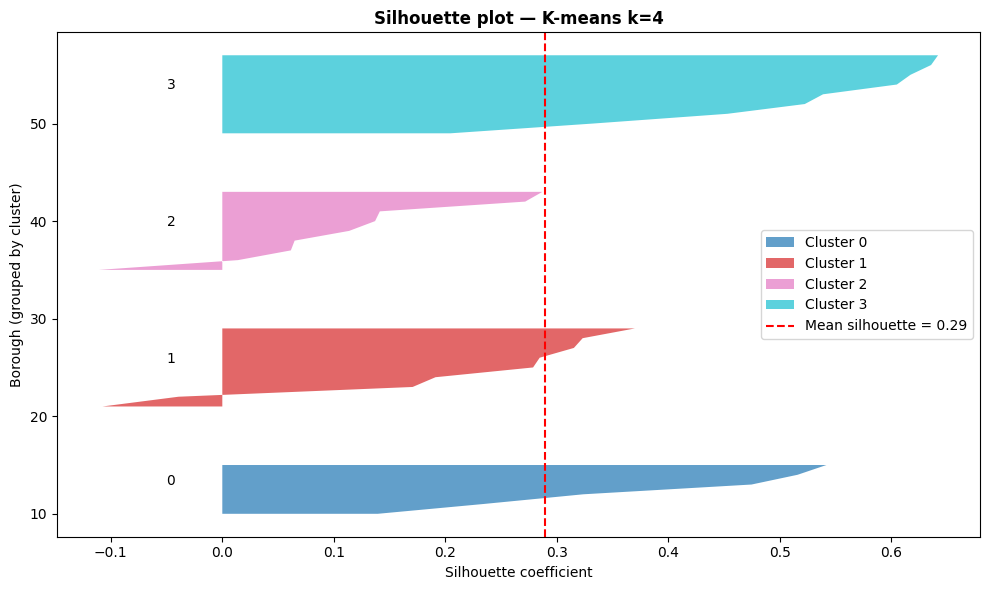

Bars extending right of the dashed line = well-matched to cluster.
Bars extending left = borderline boroughs that could belong to another cluster.


In [8]:
# Silhouette plot for best k — shows how well each borough fits its cluster
fig, ax = plt.subplots(figsize=(10, 6))

km_best = KMeans(n_clusters=best_k, random_state=42, n_init=10)
labels_best = km_best.fit_predict(X_scaled)
sil_vals = silhouette_samples(X_scaled, labels_best)

y_lower = 10
colours = plt.cm.tab10(np.linspace(0, 1, best_k))

for c in range(best_k):
    c_sil = np.sort(sil_vals[labels_best == c])
    size = c_sil.shape[0]
    y_upper = y_lower + size
    ax.fill_betweenx(np.arange(y_lower, y_upper), 0, c_sil,
                     facecolor=colours[c], alpha=0.7, label=f'Cluster {c}')
    ax.text(-0.05, y_lower + 0.5 * size, str(c))
    y_lower = y_upper + 5

ax.axvline(x=silhouette_score(X_scaled, labels_best), color='red', linestyle='--',
           label=f'Mean silhouette = {silhouette_score(X_scaled, labels_best):.2f}')
ax.set_xlabel('Silhouette coefficient')
ax.set_ylabel('Borough (grouped by cluster)')
ax.set_title(f'Silhouette plot — K-means k={best_k}', fontweight='bold')
ax.legend()
plt.tight_layout()
plt.savefig('../outputs/07_silhouette.png', dpi=150, bbox_inches='tight')
plt.show()
print('Bars extending right of the dashed line = well-matched to cluster.')
print('Bars extending left = borderline boroughs that could belong to another cluster.')

## 5. Hierarchical clustering — building the similarity tree

**What it does**: instead of picking k upfront, hierarchical clustering builds a tree (dendrogram) showing how similar every pair of boroughs is. You can then cut the tree at any height to get any number of clusters.

**Linkage method**: we use `ward` linkage, which minimises the total within-cluster variance at each merge step. This tends to produce compact, evenly-sized clusters and is the most commonly used method.

**How to read the dendrogram**: boroughs that merge low on the y-axis are very similar. The y-axis value at which two branches join is the distance between them. A large jump in height suggests a natural cluster boundary there.

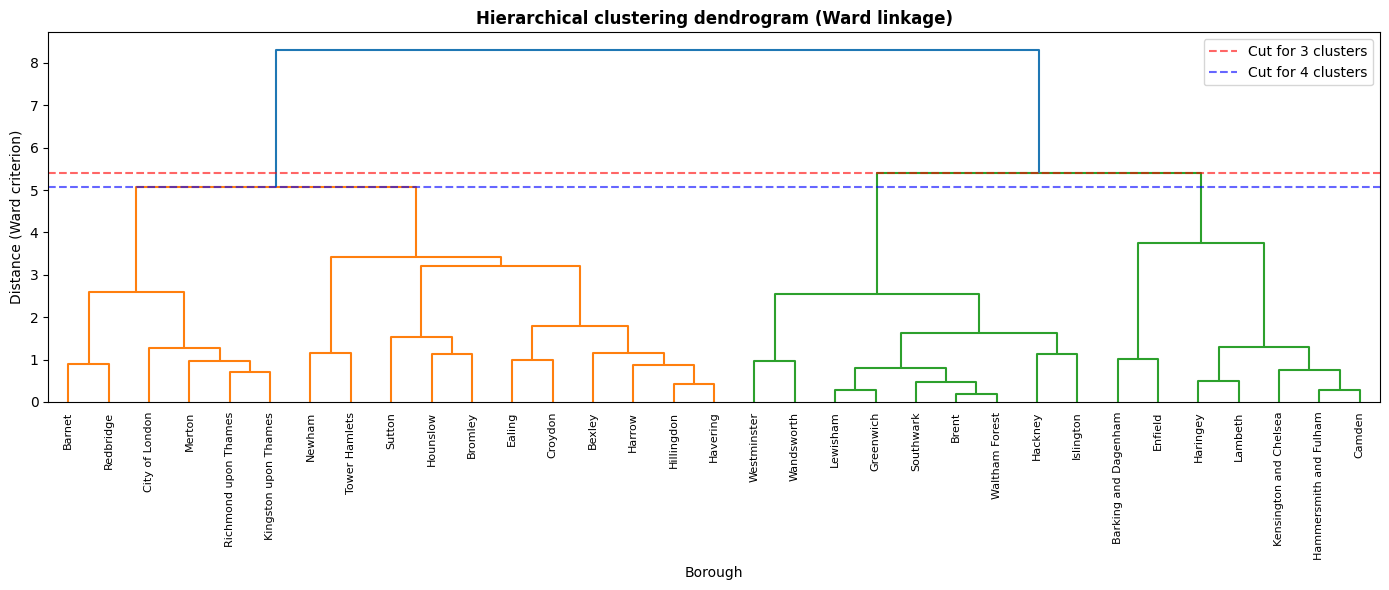

In [9]:
Z = linkage(X_scaled, method='ward')

fig, ax = plt.subplots(figsize=(14, 6))
dend = dendrogram(Z, labels=df_clean['borough'].tolist(), ax=ax,
                  color_threshold=0.7 * max(Z[:, 2]),
                  leaf_rotation=90, leaf_font_size=8)
ax.set_title('Hierarchical clustering dendrogram (Ward linkage)', fontweight='bold')
ax.set_ylabel('Distance (Ward criterion)')
ax.set_xlabel('Borough')

# Mark cut points for 3 and 4 clusters
for n_cut, colour in [(3, 'red'), (4, 'blue')]:
    cut_height = sorted(Z[:, 2], reverse=True)[n_cut - 2]
    ax.axhline(y=cut_height, color=colour, linestyle='--', alpha=0.6,
               label=f'Cut for {n_cut} clusters')

ax.legend()
plt.tight_layout()
plt.savefig('../outputs/07_dendrogram.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
for n_clusters in [3, 4]:
    hc = AgglomerativeClustering(n_clusters=n_clusters, linkage='ward')
    hc_labels = hc.fit_predict(X_scaled)

    # Order so cluster 0 = highest avg PC1
    cluster_pc1 = {c: X_pca[hc_labels == c, 0].mean() for c in range(n_clusters)}
    rank_order = sorted(cluster_pc1, key=cluster_pc1.get, reverse=True)
    remap = {old: new for new, old in enumerate(rank_order)}
    hc_ordered = np.array([remap[c] for c in hc_labels])

    df_clean[f'hc_{n_clusters}'] = hc_ordered

    tier_labels = {0: 'High priority', 1: 'Medium priority', 2: 'Lower priority', 3: 'Lowest priority'}
    print(f'\n=== Hierarchical clustering — {n_clusters} clusters ===')
    for c in sorted(set(hc_ordered)):
        boroughs_in = df_clean[df_clean[f'hc_{n_clusters}'] == c]['borough'].tolist()
        print(f'  {tier_labels[c]} ({len(boroughs_in)}): {", ".join(boroughs_in)}')


=== Hierarchical clustering — 3 clusters ===
  High priority (7): Barking and Dagenham, Haringey, Lambeth, Hammersmith and Fulham, Enfield, Kensington and Chelsea, Camden
  Medium priority (9): Hackney, Islington, Brent, Westminster, Southwark, Lewisham, Waltham Forest, Wandsworth, Greenwich
  Lower priority (17): Barnet, Newham, Redbridge, Ealing, Croydon, Merton, Richmond upon Thames, Tower Hamlets, Hillingdon, Kingston upon Thames, Harrow, Havering, City of London, Hounslow, Bexley, Bromley, Sutton

=== Hierarchical clustering — 4 clusters ===
  High priority (7): Barking and Dagenham, Haringey, Lambeth, Hammersmith and Fulham, Enfield, Kensington and Chelsea, Camden
  Medium priority (9): Hackney, Islington, Brent, Westminster, Southwark, Lewisham, Waltham Forest, Wandsworth, Greenwich
  Lower priority (6): Barnet, Redbridge, Merton, Richmond upon Thames, Kingston upon Thames, City of London
  Lowest priority (11): Newham, Ealing, Croydon, Tower Hamlets, Hillingdon, Harrow, Haveri

## 6. Side-by-side comparison — do the methods agree?

The key question: are the boroughs that appear in the high-priority group consistent across methods? If they are, that's strong evidence those boroughs genuinely need the most attention regardless of methodological choices.

In [11]:
hc_tier = {0: 'Act now', 1: 'Act next', 2: 'Monitor', 3: 'Deprioritise'}

comparison = df_clean[[
    'borough', 'priority_rank', 'pca_rank',
    f'kmeans_k{best_k}_label',
    'hc_4',
    'pct_below_epc_c', 'income_deprivation_rate', 'pct_solid_wall'
]].copy()

comparison['hc_4_label'] = comparison['hc_4'].map(hc_tier)

comparison = comparison[[
    'borough', 'priority_rank', 'pca_rank',
    f'kmeans_k{best_k}_label', 'hc_4_label',
    'pct_below_epc_c', 'income_deprivation_rate', 'pct_solid_wall'
]]

comparison.columns = [
    'Borough', 'Original rank', 'PCA rank',
    f'K-means (k={best_k})', 'Hierarchical (4 clusters)',
    '% below EPC C', 'Income deprivation', '% solid wall'
]

print('=== Full comparison ===')
print(comparison.sort_values('Original rank').to_string(index=False))

=== Full comparison ===
               Borough  Original rank  PCA rank K-means (k=4) Hierarchical (4 clusters)  % below EPC C  Income deprivation  % solid wall
  Barking and Dagenham              1         3       Act now                   Act now           56.0              0.1942          60.0
              Haringey              2         2       Act now                   Act now           48.5              0.1683          78.2
               Lambeth              3         4       Act now                   Act now           46.9              0.1563          76.0
Hammersmith and Fulham              4         6       Act now                   Act now           45.6              0.1423          77.1
               Enfield              5         9       Act now                   Act now           52.4              0.1680          62.0
Kensington and Chelsea              6        15       Act now                   Act now           46.1              0.1211          72.5
                C

In [12]:
print('=== Boroughs with largest rank shift: Original → PCA ===')
df_clean['abs_shift'] = (df_clean['pca_rank'] - df_clean['priority_rank']).abs()
print(df_clean.sort_values('abs_shift', ascending=False)
      [['borough','priority_rank','pca_rank','pct_below_epc_c','income_deprivation_rate','pct_solid_wall']]
      .head(8).to_string(index=False))

print()
print('=== Top 5 high-priority boroughs: are they consistent across all methods? ===')
top5_original = set(df_clean[df_clean['priority_rank'] <= 5]['borough'])
top5_pca      = set(df_clean[df_clean['pca_rank'] <= 5]['borough'])
top_hc        = set(df_clean[df_clean['hc_4'] == 0]['borough'])
top_km        = set(df_clean[df_clean[f'kmeans_k{best_k}'] == 0]['borough'])

print(f'Original top 5:             {sorted(top5_original)}')
print(f'PCA top 5:                  {sorted(top5_pca)}')
print(f'Hierarchical "Act now":     {sorted(top_hc)}')
print(f'K-means "Act now":          {sorted(top_km)}')
print()
print(f'Consistent across ALL methods: {sorted(top5_original & top5_pca & top_hc & top_km)}')

=== Boroughs with largest rank shift: Original → PCA ===
               borough  priority_rank  pca_rank  pct_below_epc_c  income_deprivation_rate  pct_solid_wall
                Barnet              9        23             50.3                   0.1092            54.4
Kensington and Chelsea              6        15             46.1                   0.1211            72.5
            Hillingdon             21        29             44.0                   0.1123            49.2
  Richmond upon Thames             17        25             44.8                   0.0640            64.9
                Ealing             14        22             43.7                   0.1400            51.7
             Greenwich             20        12             36.5                   0.1565            71.6
                Bexley             26        32             41.8                   0.1022            42.2
               Hackney              7         1             37.7                   0.1985      

## 7. Summary and recommendation

Which method should we use as the primary output?

In [13]:
print('=' * 65)
print('SUMMARY OF FINDINGS')
print('=' * 65)
print()
print('Correlation between EPC quality and pre-1950 stock:',
      round(df['pct_below_epc_c'].corr(df['pct_pre_1950']), 3))
print()
print('The three alternative methods agree on the core finding:')
consistent = sorted(top5_original & top5_pca & top_hc & top_km)
print(f'  {consistent}')
print('appear in the high-priority group across ALL methods.')
print()
print('Boroughs most affected by the double-counting problem:')
movers = (df_clean[df_clean['abs_shift'] >= 4]
          .sort_values('abs_shift', ascending=False)
          [['borough', 'priority_rank', 'pca_rank']])
print(movers.to_string(index=False))
print()
print('Recommendation:')
print('  K-means clustering is the most interpretable output for a housing')
print('  association audience. Rather than a precise rank (which implies false')
print('  precision), clustering groups boroughs into tiers: high / medium / lower')
print('  priority. The top cluster is stable regardless of method.')
print()
print('  PCA confirms the correlation between EPC and age accounts for')
print(f'  {pca.explained_variance_ratio_[0]:.0%} of variance in a single component,')
print('  validating the concern about double-counting.')
print()
print('  Hierarchical clustering and the dendrogram are useful for showing')
print('  HOW SIMILAR neighbouring boroughs are — a good visual for a portfolio.')

SUMMARY OF FINDINGS

Correlation between EPC quality and pre-1950 stock: 0.255

The three alternative methods agree on the core finding:
  ['Barking and Dagenham', 'Haringey', 'Lambeth']
appear in the high-priority group across ALL methods.

Boroughs most affected by the double-counting problem:
               borough  priority_rank  pca_rank
                Barnet              9        23
Kensington and Chelsea              6        15
                Ealing             14        22
  Richmond upon Thames             17        25
             Greenwich             20        12
            Hillingdon             21        29
               Hackney              7         1
                Bexley             26        32
             Redbridge             12        18
        City of London             25        31
                Merton             16        21
                Harrow             23        28
                Sutton             28        33
  Kingston upon Thames         

In [ ]:
import os
os.makedirs('outputs', exist_ok=True)

df_clean[[
    'borough', 'priority_rank', 'pca_rank',
    f'kmeans_k{best_k}_label', 'hc_4',
    'pct_below_epc_c', 'income_deprivation_rate', 'pct_solid_wall'
]].rename(columns={
    f'kmeans_k{best_k}_label': 'kmeans_tier',
    'hc_4': 'hc_cluster'
}).to_csv('outputs/borough_clustering_tiers.csv', index=False)
print('Saved outputs/borough_clustering_tiers.csv')